# HD-Referenzsätze – Worthäufigkeit & Korpusanalyse

**Forschungsfrage:**  
*«Wie gut lässt sich der dialektspezifische Wortschatz des Ostschweizer Dialekts automatisch hochdeutschen Äquivalenten zuordnen – gemessen an Wörtern mittlerer Häufigkeit?»*

Dieses Notebook analysiert die hochdeutschen Referenzsätze des Ostschweizer Teilkorpus hinsichtlich Worthäufigkeitsverteilung, Vokabular-Eigenschaften und weiterer Points of Interest (POI), die für die Forschungsfrage relevant sind.

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from wordcloud import WordCloud

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

df = pd.read_csv("Data/transcriptions_clean.csv")
df_ost = df[df["dialect_region"] == "Ostschweiz"].copy().reset_index(drop=True)

# ── Tokenisierung ─────────────────────────────────────────────────────────────
def tokenize(text):
    """Kleinbuchstaben, nur Buchstaben (inkl. Umlaute)."""
    return re.findall(r"[a-zäöüß]+", str(text).lower())

df_ost["tokens"] = df_ost["sentence"].apply(tokenize)
all_tokens = [tok for sent in df_ost["tokens"] for tok in sent]
freq = Counter(all_tokens)

print(f"Sätze:          {len(df_ost):,}")
print(f"Tokens total:   {len(all_tokens):,}")
print(f"Types (Vocab):  {len(freq):,}")
print(f"Type-Token-Ratio (TTR): {len(freq)/len(all_tokens):.4f}")

Sätze:          3,084
Tokens total:   24,731
Types (Vocab):  6,390
Type-Token-Ratio (TTR): 0.2584


## 1. Top-Wörter (inkl. Funktionswörter)

In [ ]:
top_n = 30
top_words,  top_counts  = zip(*freq.most_common(top_n))
rare_words, rare_counts = zip(*freq.most_common()[:-top_n-1:-1])  # bottom 30

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Häufigste
bars = axes[0].barh(top_words[::-1], top_counts[::-1], color="#4472C4")
axes[0].set_xlabel("Häufigkeit")
axes[0].set_title(f"Top {top_n} häufigste Wörter")
axes[0].bar_label(bars, padding=3, fontsize=8)

# Seltenste (nur Wörter mit > 1 Vorkommen, sonst Hapax-Masse)
rare_items = [(w, c) for w, c in freq.most_common() if c > 1][-top_n:]
if rare_items:
    rare_words, rare_counts = zip(*rare_items)
    bars2 = axes[1].barh(rare_words[::-1], rare_counts[::-1], color="#E74C3C")
    axes[1].set_xlabel("Häufigkeit")
    axes[1].set_title(f"Seltenste {top_n} Wörter (mit ≥ 2 Vorkommen)")
    axes[1].bar_label(bars2, padding=3, fontsize=8)

plt.suptitle("Worthäufigkeit – Extreme (Rohkorpus)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Liniendiagramm: Anzahl Wörter die genau 1x, 2x, ... 20x vorkommen
max_freq = 20
x = list(range(1, max_freq + 1))
y = [sum(1 for c in freq.values() if c == n) for n in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, marker="o", color="#4472C4", linewidth=2, markersize=6)
ax.fill_between(x, y, alpha=0.15, color="#4472C4")

for xi, yi in zip(x, y):
    ax.annotate(str(yi), xy=(xi, yi), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=8, color="#2c3e50")

ax.set_xticks(x)
ax.set_xlabel("Anzahl Vorkommen im Korpus")
ax.set_ylabel("Anzahl Wörter (Types)")
ax.set_title("Wie viele Wörter kommen genau 1×, 2×, … 20× vor?")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 3. Stopwörter entfernen – Inhaltswörter

Funktionswörter dominieren jedes natürlichsprachliche Korpus und sind für das Dialekt-Mapping wenig informativ. Wir filtern sie raus, um die relevanten Inhaltswörter sichtbar zu machen.

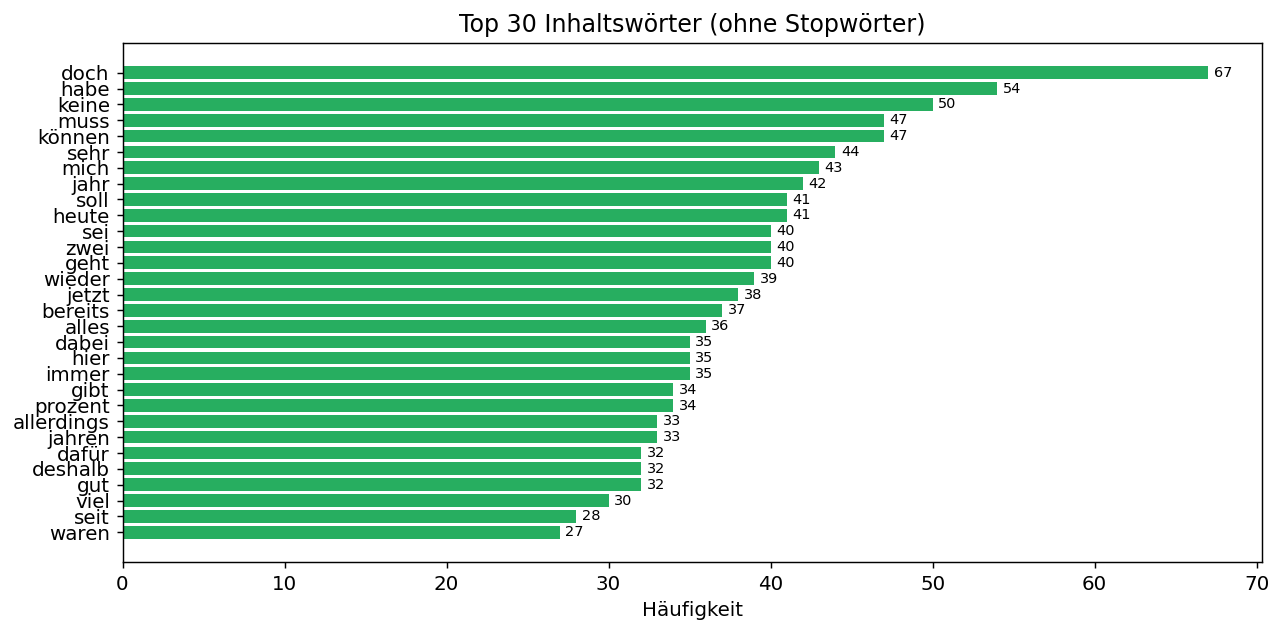

Vokabular nach Stopwort-Filter: 6,229 Types


In [4]:
DE_STOPWORDS = {
    "der", "die", "das", "ein", "eine", "einen", "einem", "einer", "eines",
    "und", "oder", "aber", "auch", "nicht", "noch", "als", "an", "auf",
    "aus", "bei", "bis", "da", "damit", "dann", "dass", "dem", "den",
    "des", "durch", "er", "es", "für", "hat", "haben", "hatte", "hatten",
    "ich", "im", "in", "ist", "ja", "kann", "mit", "nach", "nicht",
    "nun", "ob", "oder", "schon", "sein", "seine", "seiner", "seinem",
    "seinen", "seines", "sich", "sie", "sind", "so", "um", "und", "uns",
    "unter", "von", "vor", "war", "was", "weil", "wenn", "werden",
    "wie", "wir", "wird", "wo", "zu", "zum", "zur", "über",
    "am", "vom", "ins", "beim", "seiner", "ihren", "ihrer", "ihrem",
    "ihre", "ihr", "ihn", "ihm", "man", "mehr", "nur", "ohne", "werden",
    "wurde", "wurden", "worden", "worden", "dieses", "diesem", "diesen",
    "dieser", "diesen", "diese", "dies", "zwischen", "jedoch",
}

content_freq = Counter({w: c for w, c in freq.items() if w not in DE_STOPWORDS and len(w) > 2})

top_content = content_freq.most_common(30)
words_c, counts_c = zip(*top_content)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(words_c[::-1], counts_c[::-1], color="#27AE60")
ax.set_xlabel("Häufigkeit")
ax.set_title("Top 30 Inhaltswörter (ohne Stopwörter)")
ax.bar_label(bars, padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Vokabular nach Stopwort-Filter: {len(content_freq):,} Types")

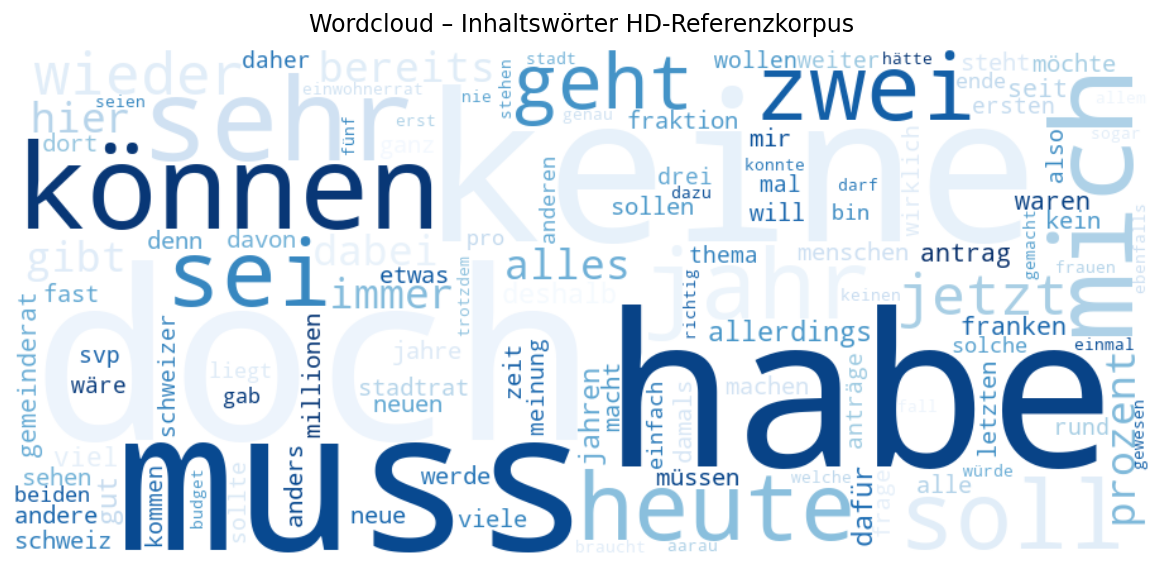

In [5]:
# Wordcloud der Inhaltswörter
wc = WordCloud(
    width=900, height=400,
    background_color="white",
    colormap="Blues",
    max_words=120,
    prefer_horizontal=0.85,
).generate_from_frequencies(content_freq)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Wordcloud – Inhaltswörter HD-Referenzkorpus", pad=10)
plt.tight_layout()
plt.show()

## 4. POI: Mittlere Häufigkeit (Kern der Forschungsfrage)

Wörter mit mittlerer Häufigkeit (hier: 5–50 Vorkommen) sind besonders relevant:
- **Zu selten (< 5)**: kaum Evidenz für automatisches Mapping, hohe Fehlerrate
- **Zu häufig (> 50)**: meist Funktionswörter, dialektunspezifisch  
- **Mittleres Band**: inhaltstragende Wörter mit genug Evidenz → interessantestes Segment

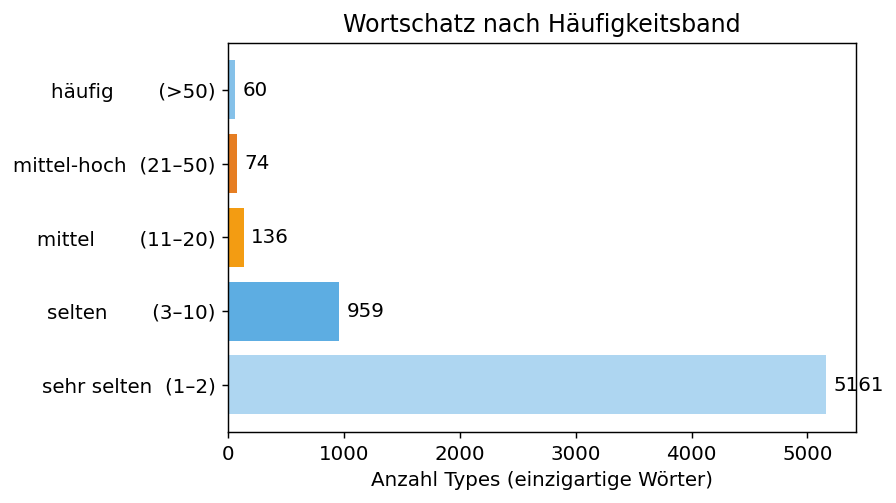

  sehr selten  (1–2)   5,161  (80.8%)
  selten       (3–10)     959  (15.0%)
  mittel       (11–20)     136  (2.1%)
  mittel-hoch  (21–50)      74  (1.2%)
  häufig       (>50)      60  (0.9%)

Inhaltswörter im mittleren Band (5–50): 544 Types

       Wort  Häufigkeit
      keine          50
       muss          47
     können          47
       sehr          44
       mich          43
       jahr          42
      heute          41
       soll          41
        sei          40
       geht          40
       zwei          40
     wieder          39
      jetzt          38
    bereits          37
      alles          36
      immer          35
      dabei          35
       hier          35
       gibt          34
    prozent          34
     jahren          33
 allerdings          33
      dafür          32
    deshalb          32
        gut          32
       viel          30
       seit          28
     antrag          27
    franken          27
gemeinderat          27
      waren 

In [6]:
MID_LOW, MID_HIGH = 5, 50

bands = {
    "sehr selten  (1–2)":  sum(1 for c in freq.values() if c <= 2),
    "selten       (3–10)": sum(1 for c in freq.values() if 3 <= c <= 10),
    "mittel       (11–20)":sum(1 for c in freq.values() if 11 <= c <= 20),
    "mittel-hoch  (21–50)":sum(1 for c in freq.values() if 21 <= c <= 50),
    "häufig       (>50)":  sum(1 for c in freq.values() if c > 50),
}

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#AED6F1", "#5DADE2", "#F39C12", "#E67E22", "#85C1E9"]
bars = ax.barh(list(bands.keys()), list(bands.values()), color=colors)
ax.set_xlabel("Anzahl Types (einzigartige Wörter)")
ax.set_title("Wortschatz nach Häufigkeitsband")
ax.bar_label(bars, padding=4)
plt.tight_layout()
plt.show()

for label, count in bands.items():
    print(f"  {label}   {count:>5,}  ({count/len(freq)*100:.1f}%)")

# Mittlere Inhaltswörter als DataFrame (5–50 bleibt der Kern für die Forschungsfrage)
mid_content = {
    w: c for w, c in content_freq.items()
    if MID_LOW <= c <= MID_HIGH
}
df_mid = (
    pd.DataFrame(mid_content.items(), columns=["Wort", "Häufigkeit"])
    .sort_values("Häufigkeit", ascending=False)
    .reset_index(drop=True)
)
print(f"\nInhaltswörter im mittleren Band ({MID_LOW}–{MID_HIGH}): {len(df_mid)} Types\n")
print(df_mid.head(40).to_string(index=False))

## 5. POI: Satz- und Wortlängenverteilung

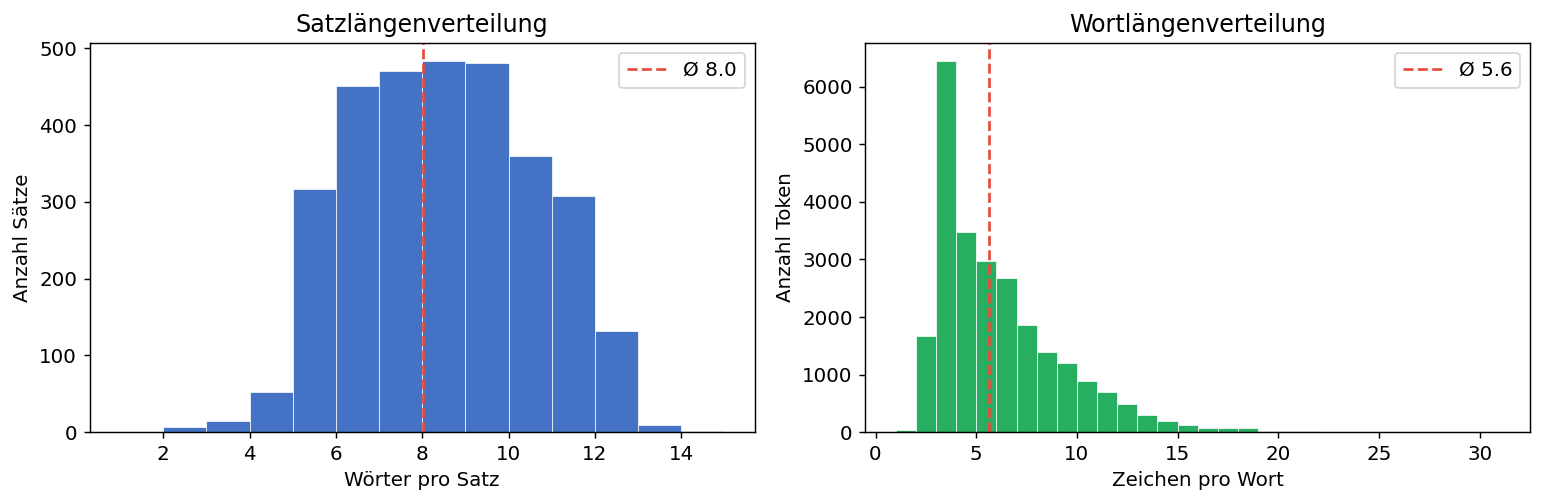

Satzlänge:  Ø 8.0 | Median 8 | Max 14
Wortlänge:  Ø 5.6 | Median 5 | Max 30


In [8]:
sent_lengths = df_ost["tokens"].apply(len)
word_lengths = pd.Series([len(w) for w in all_tokens])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Satzlänge
axes[0].hist(sent_lengths, bins=range(1, sent_lengths.max() + 2), color="#4472C4", edgecolor="white", linewidth=0.4)
axes[0].axvline(sent_lengths.mean(), color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Ø {sent_lengths.mean():.1f}")
axes[0].set_xlabel("Wörter pro Satz")
axes[0].set_ylabel("Anzahl Sätze")
axes[0].set_title("Satzlängenverteilung")
axes[0].legend()

# Wortlänge
axes[1].hist(word_lengths, bins=range(1, word_lengths.max() + 2), color="#27AE60", edgecolor="white", linewidth=0.4)
axes[1].axvline(word_lengths.mean(), color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Ø {word_lengths.mean():.1f}")
axes[1].set_xlabel("Zeichen pro Wort")
axes[1].set_ylabel("Anzahl Token")
axes[1].set_title("Wortlängenverteilung")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Satzlänge:  Ø {sent_lengths.mean():.1f} | Median {sent_lengths.median():.0f} | Max {sent_lengths.max()}")
print(f"Wortlänge:  Ø {word_lengths.mean():.1f} | Median {word_lengths.median():.0f} | Max {word_lengths.max()}")

## 6. POI: Hapax Legomena & Singleton-Rate

Hapax Legomena (Wörter die nur einmal vorkommen) sind ein Indikator für Korpusgrösse und lexikalische Diversität. Für das Mapping sind sie problematisch – kein Auto-Mapping möglich.

Hapax Legomena (n=1):  4,200  (65.7 % des Vokabulars)
Dis Legomena  (n=2):   961  (15.0 %)
Singletons decken     16.98 % aller Token-Vorkommen


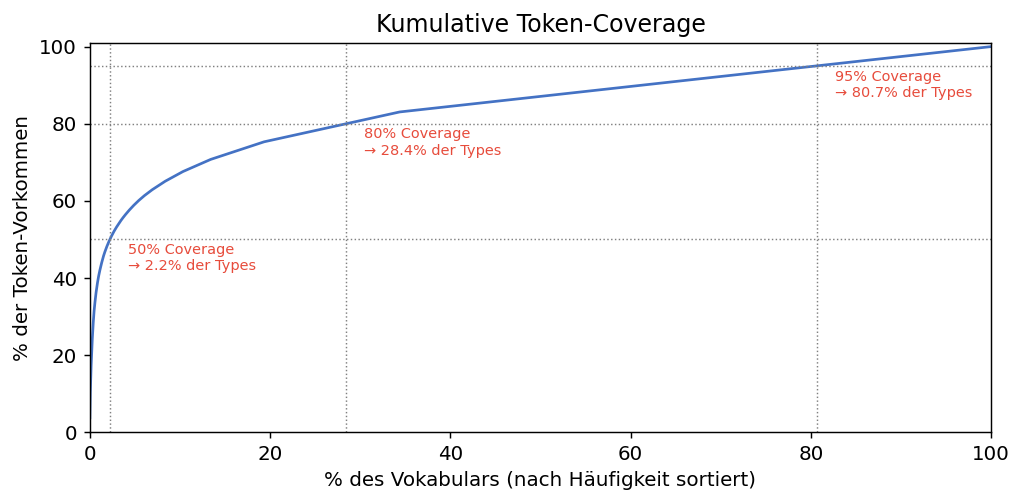

In [9]:
hapax      = [w for w, c in freq.items() if c == 1]
dis_legom  = [w for w, c in freq.items() if c == 2]

print(f"Hapax Legomena (n=1):  {len(hapax):,}  ({len(hapax)/len(freq)*100:.1f} % des Vokabulars)")
print(f"Dis Legomena  (n=2):   {len(dis_legom):,}  ({len(dis_legom)/len(freq)*100:.1f} %)")
print(f"Singletons decken     {len(hapax)/len(all_tokens)*100:.2f} % aller Token-Vorkommen")

# Kumulative Coverage-Kurve
sorted_counts = sorted(freq.values(), reverse=True)
cumulative    = np.cumsum(sorted_counts) / len(all_tokens) * 100
x_pct         = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_pct, cumulative, color="#4472C4", linewidth=1.5)
for cov in [50, 80, 95]:
    idx = np.searchsorted(cumulative, cov)
    ax.axhline(cov, color="grey", linestyle=":", linewidth=0.8)
    ax.axvline(x_pct[idx], color="grey", linestyle=":", linewidth=0.8)
    ax.annotate(f"{cov}% Coverage\n→ {x_pct[idx]:.1f}% der Types",
                xy=(x_pct[idx], cov), xytext=(x_pct[idx] + 2, cov - 8),
                fontsize=8, color="#E74C3C")

ax.set_xlabel("% des Vokabulars (nach Häufigkeit sortiert)")
ax.set_ylabel("% der Token-Vorkommen")
ax.set_title("Kumulative Token-Coverage")
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
plt.tight_layout()
plt.show()

## 7. POI: Häufigste Bigramme (Inhaltswörter)

Bigramme können zusammengesetzte Ausdrücke und typische Kollokationen im Corpus zeigen.

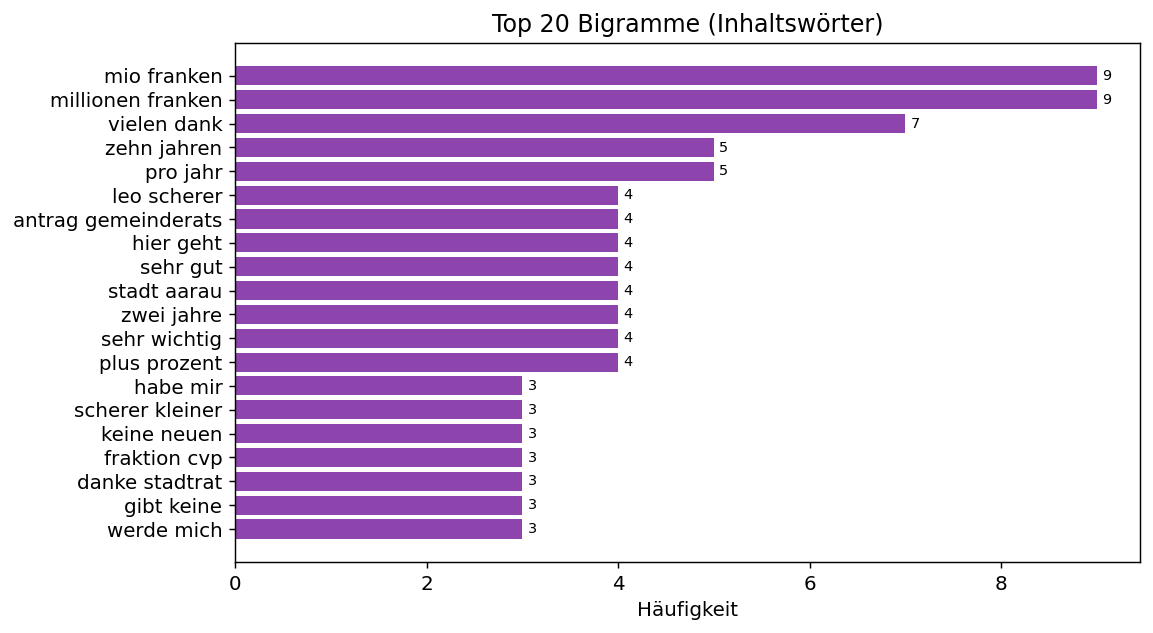

In [10]:
bigram_freq = Counter()
for tokens in df_ost["tokens"]:
    content_tokens = [t for t in tokens if t not in DE_STOPWORDS and len(t) > 2]
    for a, b in zip(content_tokens, content_tokens[1:]):
        bigram_freq[(a, b)] += 1

top_bigrams = bigram_freq.most_common(20)
bg_labels   = [f"{a} {b}" for (a, b), _ in top_bigrams]
bg_counts   = [c for _, c in top_bigrams]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(bg_labels[::-1], bg_counts[::-1], color="#8E44AD")
ax.set_xlabel("Häufigkeit")
ax.set_title("Top 20 Bigramme (Inhaltswörter)")
ax.bar_label(bars, padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 8. Zusammenfassung

In [11]:
mid_total     = sum(1 for c in freq.values() if MID_LOW <= c <= MID_HIGH)
mid_content_n = len(df_mid)
coverage_pct  = len(covered) / len(mid_words) * 100 if mid_words else 0

print("=" * 55)
print("  Korpus-Zusammenfassung")
print("=" * 55)
print(f"  Sätze (Ostschweiz):          {len(df_ost):>6,}")
print(f"  Token total:                 {len(all_tokens):>6,}")
print(f"  Vokabular (Types):           {len(freq):>6,}")
print(f"  Type-Token-Ratio:            {len(freq)/len(all_tokens):>8.4f}")
print(f"  Ø Satzlänge (Tokens):        {sent_lengths.mean():>8.1f}")
print(f"  Ø Wortlänge (Zeichen):       {word_lengths.mean():>8.1f}")
print()
print("  Häufigkeitsbänder:")
for label, count in bands.items():
    print(f"    {label}   {count:>5,}  ({count/len(freq)*100:.1f}%)")
print()
print(f"  Hapax Legomena:              {len(hapax):>6,}  ({len(hapax)/len(freq)*100:.1f}% des Vokab.)")
print(f"  Wörter im mittl. Band:       {mid_total:>6,}  ({mid_total/len(freq)*100:.1f}% des Vokab.)")
print(f"  Mittl. Inhaltswörter:        {mid_content_n:>6,}")
print(f"  Auto-Mapping-Abdeckung:      {coverage_pct:>7.1f}%")
print("=" * 55)

  Korpus-Zusammenfassung
  Sätze (Ostschweiz):           3,084
  Token total:                 24,731
  Vokabular (Types):            6,390
  Type-Token-Ratio:              0.2584
  Ø Satzlänge (Tokens):             8.0
  Ø Wortlänge (Zeichen):            5.6

  Häufigkeitsbänder:
    sehr selten  (1–2)   5,161  (80.8%)
    selten       (3–10)     959  (15.0%)
    mittel       (11–20)     136  (2.1%)
    mittel-hoch  (21–50)      74  (1.2%)
    häufig       (>50)      60  (0.9%)

  Hapax Legomena:               4,200  (65.7% des Vokab.)
  Wörter im mittl. Band:          593  (9.3% des Vokab.)
  Mittl. Inhaltswörter:           544
  Auto-Mapping-Abdeckung:          0.0%
